In [3]:
import pandas as pd

df = pd.read_csv(
    "dataset/retail_sales.csv",
    sep=";",
    encoding="latin1"
)

print(df.shape)
print(df.columns.tolist())
df.head()

(1000, 16)
['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age', 'Product Category', 'Quantity', 'Price per Unit', 'Total Amount', 'Day', 'Day_Sort', 'Month', 'Month_sort', 'Age_Group', 'Quantity_Category', 'Weekday_flag']


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Day,Day_Sort,Month,Month_sort,Age_Group,Quantity_Category,Weekday_flag
0,1,2023/11/24,CUST001,Male,34,Beauty,3,50,150,Friday,5,November,11,2534,Few Items,Weekday
1,2,2023/02/27,CUST002,Female,26,Clothing,2,500,1000,Monday,1,February,2,2534,Few Items,Weekday
2,3,2023/01/13,CUST003,Male,50,Electronics,1,30,30,Friday,5,January,1,4554,Single Item,Weekday
3,4,2023/05/21,CUST004,Male,37,Clothing,1,500,500,Sunday,7,May,5,3544,Single Item,Weekend
4,5,2023/05/06,CUST005,Male,30,Beauty,2,50,100,Saturday,6,May,5,2534,Few Items,Weekend


DATASET SHAPE
(1000, 16)

FIRST 5 ROWS
   Transaction ID        Date Customer ID  Gender  Age Product Category  \
0               1  2023/11/24     CUST001    Male   34           Beauty   
1               2  2023/02/27     CUST002  Female   26         Clothing   
2               3  2023/01/13     CUST003    Male   50      Electronics   
3               4  2023/05/21     CUST004    Male   37         Clothing   
4               5  2023/05/06     CUST005    Male   30           Beauty   

   Quantity  Price per Unit  Total Amount       Day  Day_Sort     Month  \
0         3              50           150    Friday         5  November   
1         2             500          1000    Monday         1  February   
2         1              30            30    Friday         5   January   
3         1             500           500    Sunday         7       May   
4         2              50           100  Saturday         6       May   

   Month_sort Age_Group Quantity_Category Weekday_flag  
0 

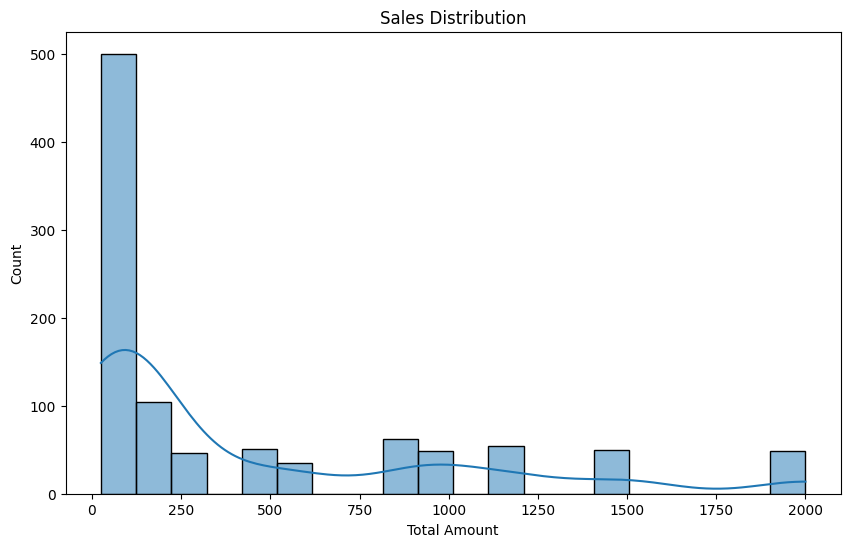

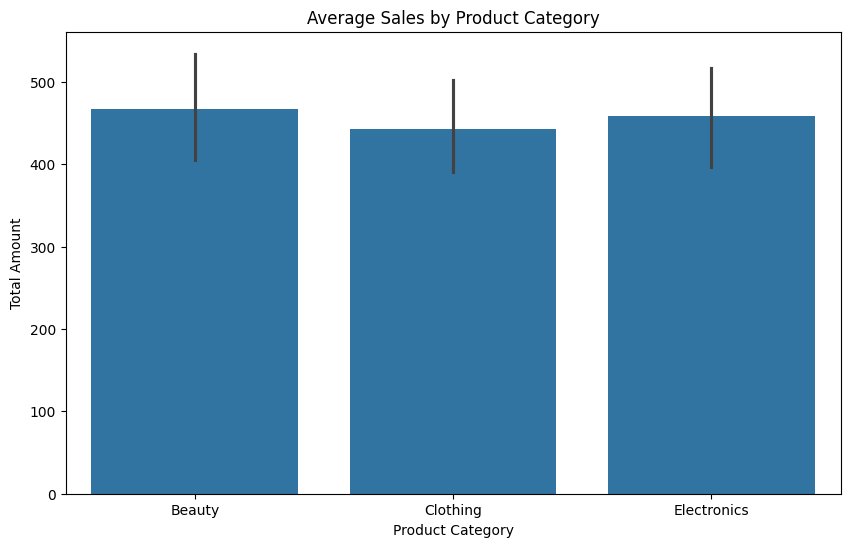

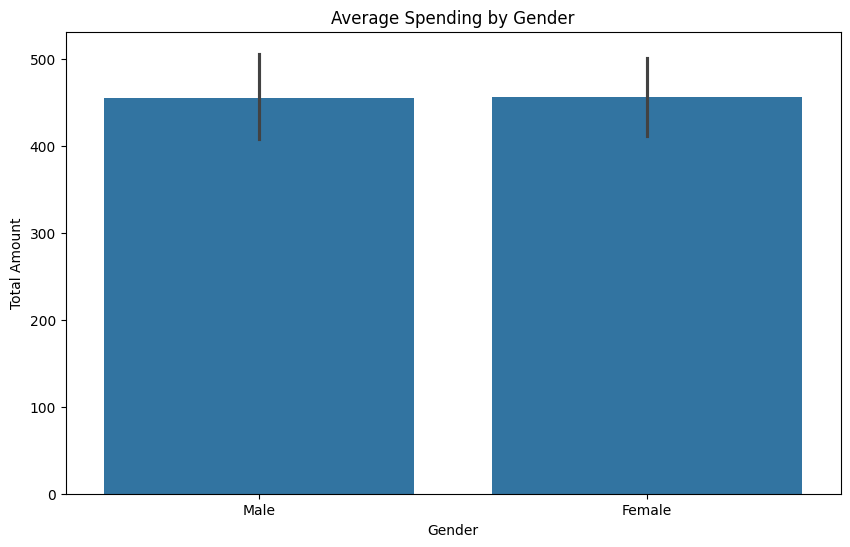

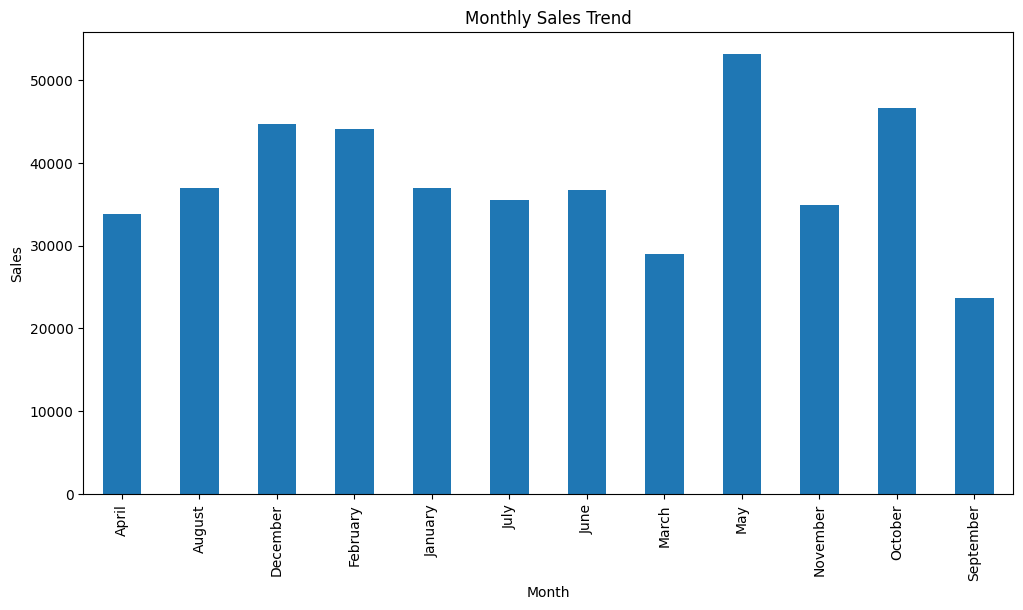

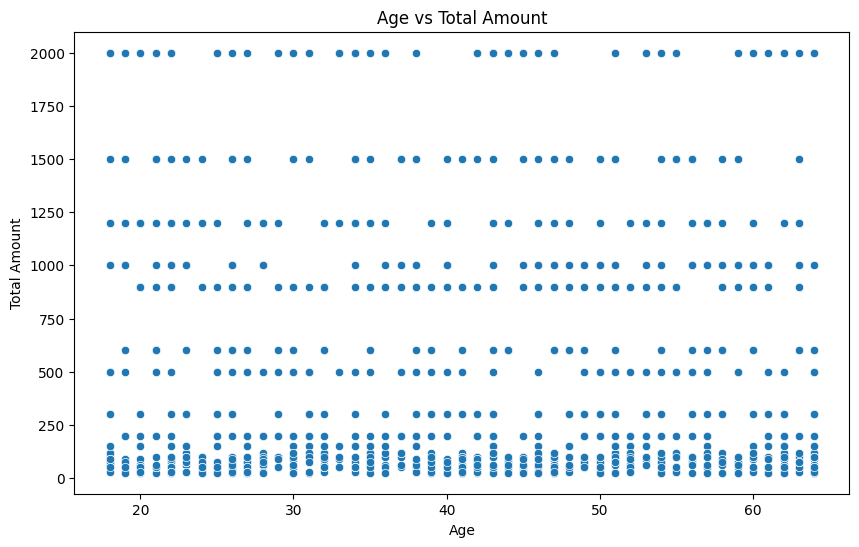

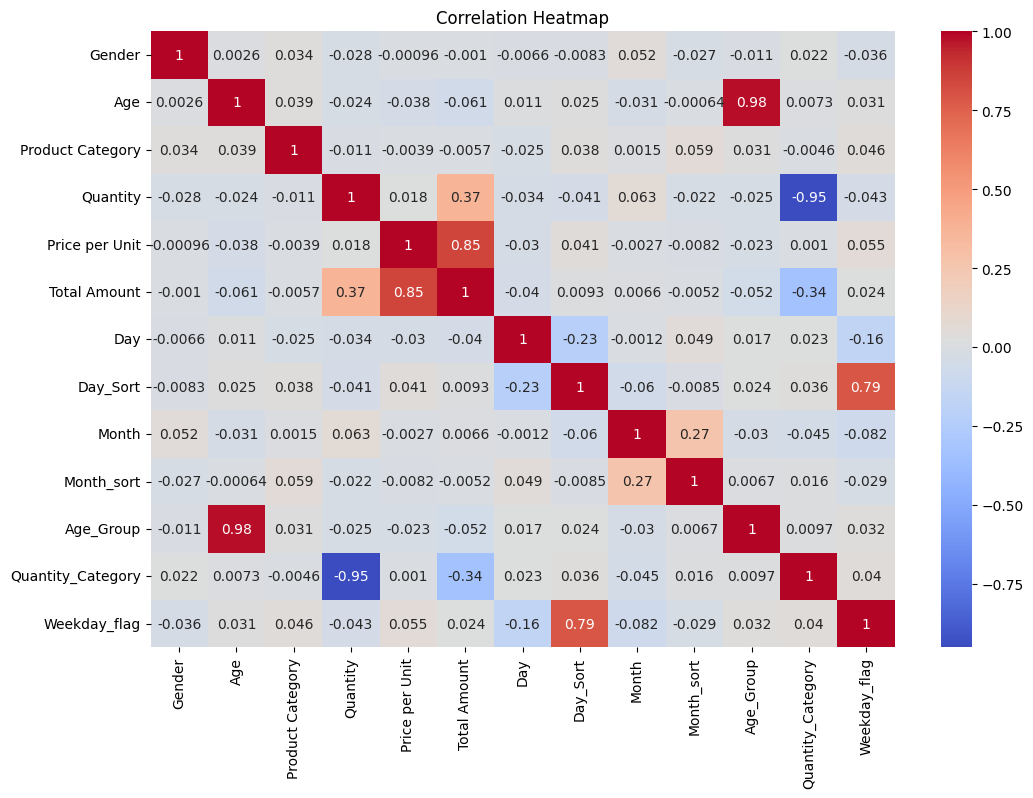


MODEL RESULTS
               Model  R2 Score
0  Linear Regression  0.854588
1      Decision Tree  1.000000
2      Random Forest  1.000000


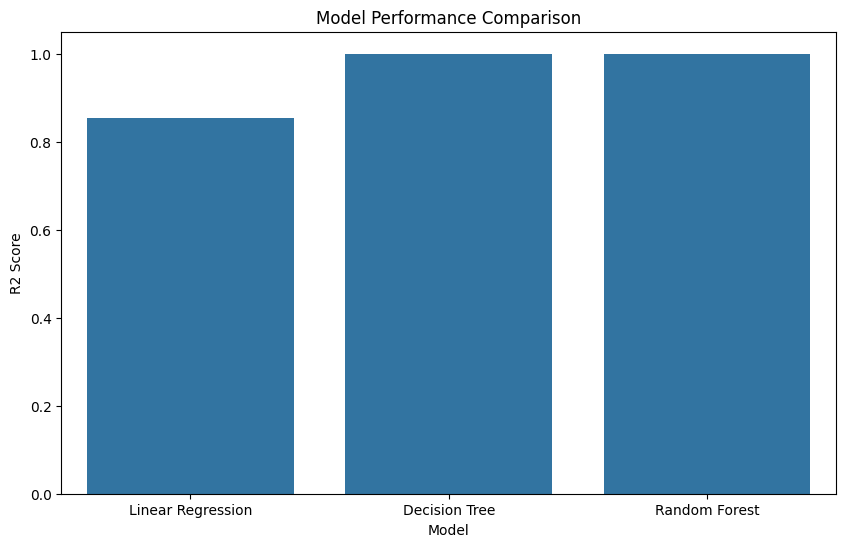

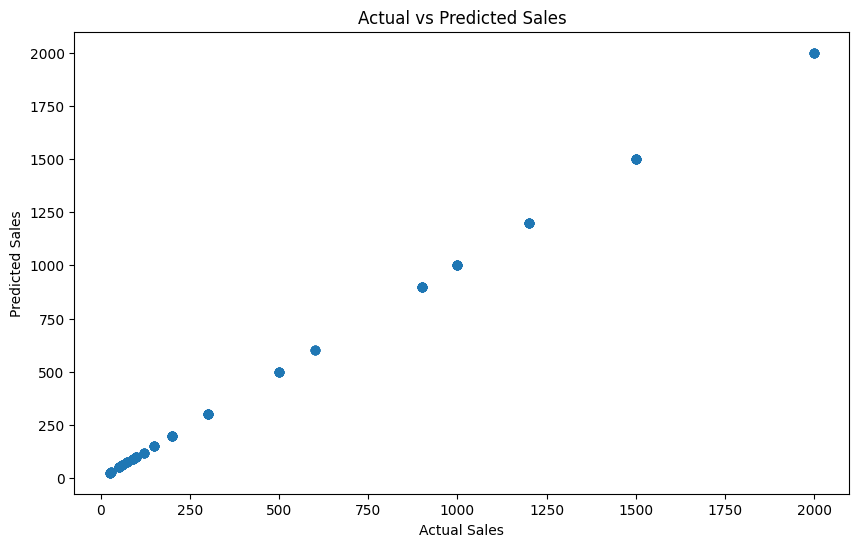

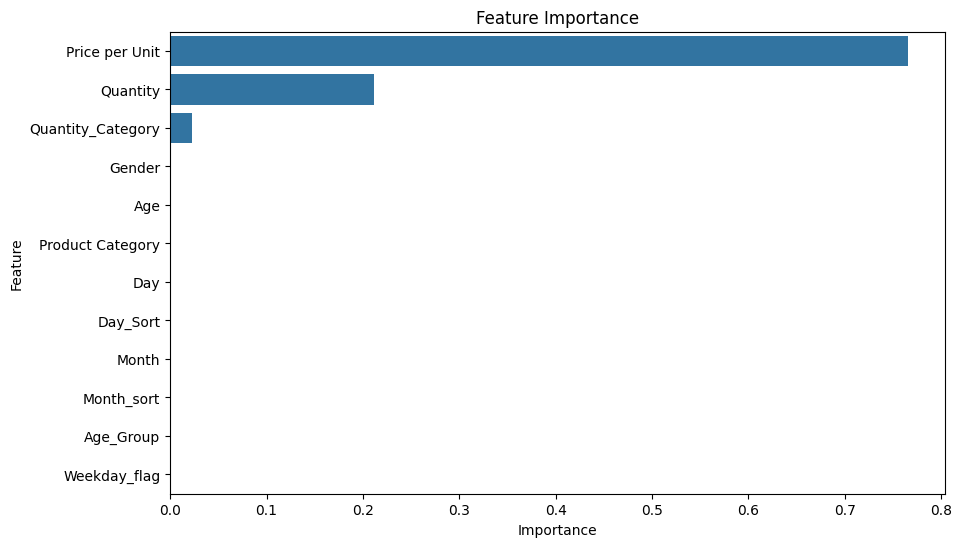


MODELS SAVED

PROJECT COMPLETED SUCCESSFULLY


In [4]:
# ==========================================
# WEEK 4 - RETAIL SALES ANALYSIS & PREDICTION
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

# ==========================================
# CREATE FOLDERS
# ==========================================

os.makedirs("visuals", exist_ok=True)
os.makedirs("models", exist_ok=True)
os.makedirs("cleaned_data", exist_ok=True)

# ==========================================
# LOAD DATASET
# ==========================================

df = pd.read_csv(
    "dataset/retail_sales.csv",
    sep=";",
    encoding="latin1"
)

print("="*50)
print("DATASET SHAPE")
print("="*50)
print(df.shape)

print("\nFIRST 5 ROWS")
print(df.head())

# ==========================================
# DATASET INFO
# ==========================================

print("\nINFO")
print(df.info())

print("\nMISSING VALUES")
print(df.isnull().sum())

print("\nDUPLICATES:", df.duplicated().sum())

# ==========================================
# DATA CLEANING
# ==========================================

df.drop_duplicates(inplace=True)

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

# ==========================================
# REMOVE USELESS COLUMNS
# ==========================================

drop_cols = [
    "Transaction ID",
    "Customer ID",
    "Date"
]

df.drop(columns=drop_cols, inplace=True)

# ==========================================
# ENCODE CATEGORICAL FEATURES
# ==========================================

le = LabelEncoder()

categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# ==========================================
# SALES DISTRIBUTION
# ==========================================

plt.figure(figsize=(10,6))

sns.histplot(
    df["Total Amount"],
    kde=True,
    bins=20
)

plt.title("Sales Distribution")

plt.savefig(
    "visuals/sales_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ==========================================
# PRODUCT CATEGORY SALES
# ==========================================

raw_df = pd.read_csv(
    "dataset/retail_sales.csv",
    sep=";",
    encoding="latin1"
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=raw_df,
    x="Product Category",
    y="Total Amount",
    estimator=np.mean
)

plt.title("Average Sales by Product Category")

plt.savefig(
    "visuals/category_sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ==========================================
# GENDER SALES
# ==========================================

plt.figure(figsize=(10,6))

sns.barplot(
    data=raw_df,
    x="Gender",
    y="Total Amount",
    estimator=np.mean
)

plt.title("Average Spending by Gender")

plt.savefig(
    "visuals/gender_sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ==========================================
# MONTHLY SALES TREND
# ==========================================

monthly_sales = raw_df.groupby(
    "Month"
)["Total Amount"].sum()

plt.figure(figsize=(12,6))

monthly_sales.plot(kind="bar")

plt.title("Monthly Sales Trend")

plt.ylabel("Sales")

plt.savefig(
    "visuals/monthly_sales_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ==========================================
# AGE VS SALES
# ==========================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=raw_df,
    x="Age",
    y="Total Amount"
)

plt.title("Age vs Total Amount")

plt.savefig(
    "visuals/age_vs_sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ==========================================
# CORRELATION HEATMAP
# ==========================================

plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.savefig(
    "visuals/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ==========================================
# FEATURES & TARGET
# ==========================================

X = df.drop(columns=["Total Amount"])

y = df["Total Amount"]

# ==========================================
# TRAIN TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ==========================================
# TRAIN MODELS
# ==========================================

lr = LinearRegression()

dt = DecisionTreeRegressor(
    random_state=42
)

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

lr.fit(X_train, y_train)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)

# ==========================================
# PREDICTIONS
# ==========================================

lr_pred = lr.predict(X_test)

dt_pred = dt.predict(X_test)

rf_pred = rf.predict(X_test)

# ==========================================
# MODEL COMPARISON
# ==========================================

results = pd.DataFrame({

    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "R2 Score": [

        r2_score(y_test, lr_pred),

        r2_score(y_test, dt_pred),

        r2_score(y_test, rf_pred)
    ]
})

print("\nMODEL RESULTS")
print(results)

# ==========================================
# MODEL COMPARISON CHART
# ==========================================

plt.figure(figsize=(10,6))

sns.barplot(
    data=results,
    x="Model",
    y="R2 Score"
)

plt.title("Model Performance Comparison")

plt.savefig(
    "visuals/model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ==========================================
# ACTUAL VS PREDICTED
# ==========================================

plt.figure(figsize=(10,6))

plt.scatter(
    y_test,
    rf_pred
)

plt.xlabel("Actual Sales")

plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted Sales")

plt.savefig(
    "visuals/actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ==========================================
# FEATURE IMPORTANCE
# ==========================================

importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": rf.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.savefig(
    "visuals/feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ==========================================
# SAVE CLEANED DATA
# ==========================================

df.to_csv(
    "cleaned_data/retail_sales_cleaned.csv",
    index=False
)

# ==========================================
# SAVE MODELS
# ==========================================

joblib.dump(
    lr,
    "models/linear_regression.pkl"
)

joblib.dump(
    dt,
    "models/decision_tree.pkl"
)

joblib.dump(
    rf,
    "models/random_forest.pkl"
)

print("\nMODELS SAVED")

print("\nPROJECT COMPLETED SUCCESSFULLY")